# Lab 7b: ML Algorithm Comparison

## Introduction
We will use K-fold cross validation to compare 3 algorithms: logistic regression (LR), K nearest neigbours (KNN) and Naive Bayes (NB). The cross validation (CV) scores obtained can then be used as a criteria for model selection for future work. The Pima Indian diabetes dataset is used.

## Part 1 (demo)

* Firstly import the packages to be used.

In [8]:
from pandas import read_csv
from matplotlib import pyplot
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

* Load the dataset.

In [9]:
filename = 'pima-indians-diabetes.data.csv'
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
df = read_csv(filename, names=names)
array = df.values
X = array[:,0:8]
Y = array[:,8]

* Prepare the models.

In [10]:
models = []
models.append(('LR', LogisticRegression(solver='lbfgs', max_iter=10000)))
models.append(('KNN', KNeighborsClassifier()))
models.append(('NB', GaussianNB()))

* Evaluate each model in turn and display the results including the mean accuraries and mean standard deviations.

In [11]:
results = []
names = []
scoring = 'accuracy'
for name, model in models:
    kfold = KFold(n_splits=10, random_state=7, shuffle=True)
    cv_results = cross_val_score(model, X, Y, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

LR: 0.772163 (0.049684)
KNN: 0.710988 (0.050792)
NB: 0.759142 (0.038960)


* Display the boxplots for comparison.

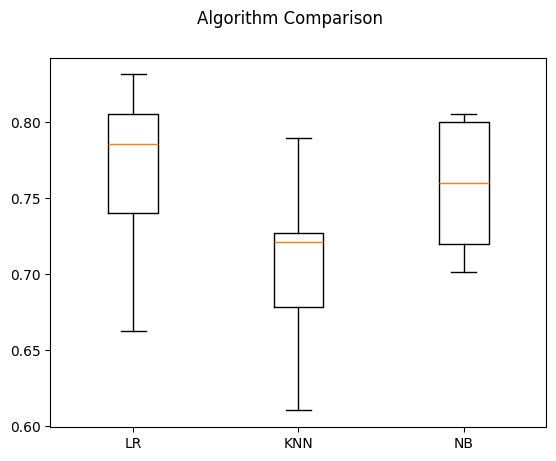

In [12]:
fig = pyplot.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
pyplot.show()

## Part 2 (Exercise)

### Note: Please first restart the kernel and then run all the cells (menu: Cell > Run All) before doing the exercise.

## Question 1
From the results obtained in the demo, which algorithm would you select for training a model?  

LR Mean Accuracy = 0.772163, Standard Deviation = 0.049684
KNN Mean Accuracy = 0.710988, Standard Deviation = 0.050792
NB Mean Accuracy = 0.759142, Standard Deviation = 0.038960

## Question 2
Now try to use the breast_cancer dataset from scikit-learn. Write and run the code in the cell below to
* import any extra package(s) to be used.

In [13]:
### BEGIN SOLUTION
from sklearn.datasets import load_breast_cancer
### END SOLUTION

## Question 3
Write and run the code in the cell below to
* load the dataset. Use only the first 200 rows of data for evaluation later.

In [14]:
### BEGIN SOLUTION
data = load_breast_cancer()
X = data.data[:200]
Y = data.target[:200]
### END SOLUTION

## Question 4
Write and run the code in the cell below to
* prepare the 3 models as in the demo.

In [15]:
### BEGING SOLUTION
models = []
models.append(('LR', LogisticRegression(solver='lbfgs', max_iter=10000)))
models.append(('KNN', KNeighborsClassifier()))
models.append(('NB', GaussianNB()))
### END SOLUTION

## Question 5
Write and run the code in the cell below to
* evaluate each model with a 5-fold cross validation in turn, and
* display the boxplots for comparison.

LR: 0.945000 (0.043012)
KNN: 0.915000 (0.040620)
NB: 0.915000 (0.046368)


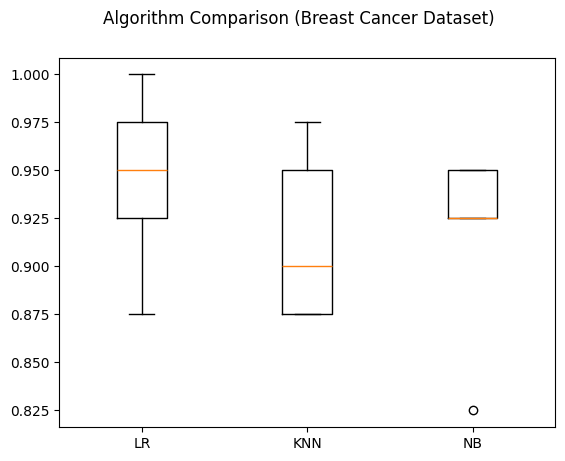

In [16]:
### BEGIN SOLUTION
results = []
names = []
scoring = 'accuracy'
for name, model in models:
    kfold = KFold(n_splits=5, random_state=7, shuffle=True) # 5-fold cross validation
    cv_results = cross_val_score(model, X, Y, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

fig = pyplot.figure()
fig.suptitle('Algorithm Comparison (Breast Cancer Dataset)')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
pyplot.show()
### END SOLUTION

## Question 6
Which algorithm will you select for training a model based on these results?

I need to run the code in the previous cell first to see the evaluation results